In [2]:
import os
target_path = '/users/lorin.ng/SURIP2026/data'
os.chdir(target_path)
print(f"current directory: {os.getcwd()}")

current directory: /users/lorin.ng/SURIP2026/data


Plot saved as 'logB_8d_comparison.png' in '../plots/'.


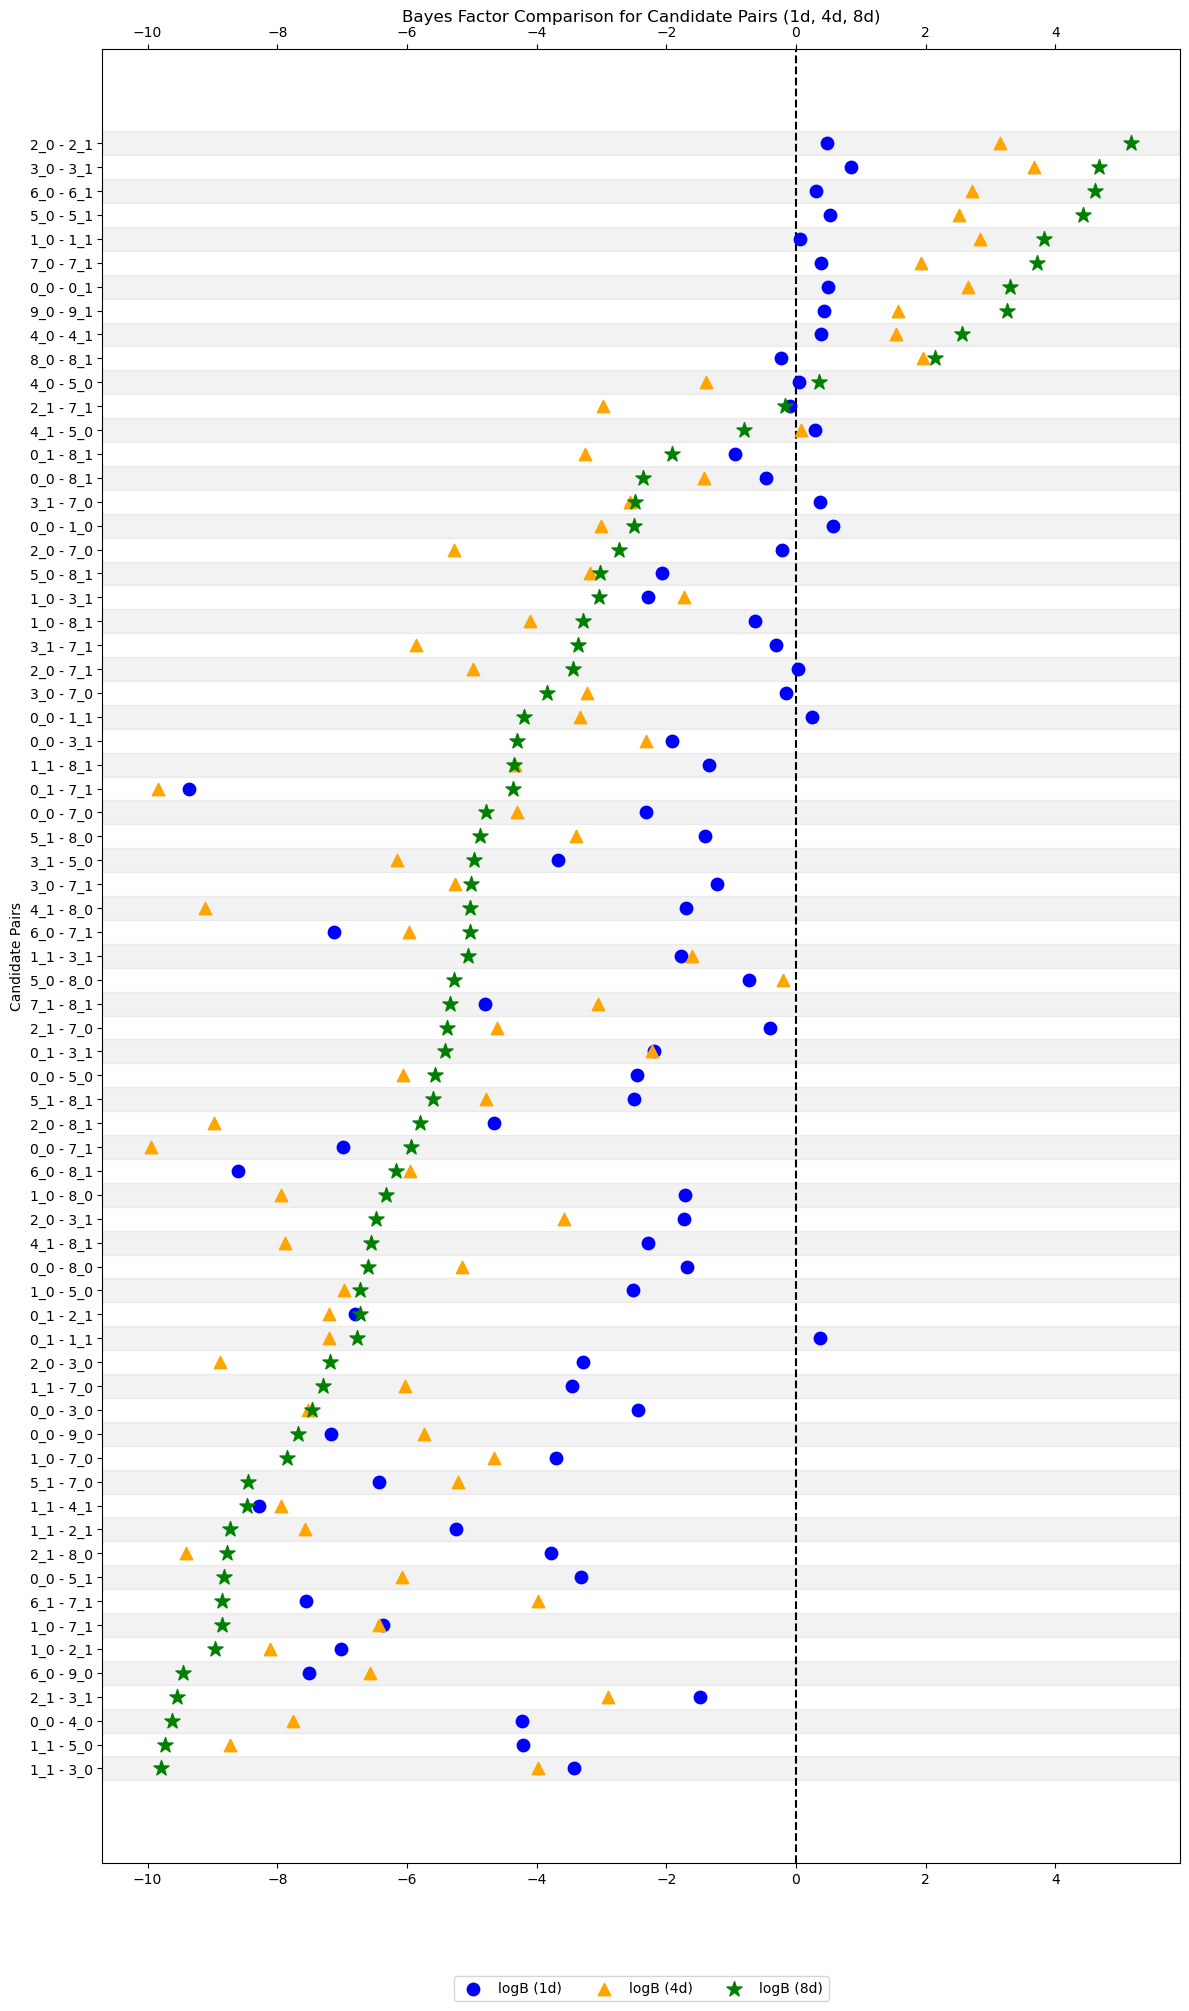

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
a= -10

df = pd.read_csv("../plots/bayes_factor_8d_results.csv")
df = df[(df['logB (1d)'] > a) & (df['logB (4d)'] > a) & (df['logB (8d)'] > a)].sort_values(by='logB (8d)', ascending=False)
y_pos = np.arange(len(df))
df['pair label'] = df['Signal_0'].astype(str) + " - " + df['Signal_1'].astype(str)

fig, ax = plt.subplots(figsize=(12, 20))
for i in range(len(df)):
    if i % 2 == 0:
        ax.axhspan(i - 0.5, i + 0.5, color='gray', alpha=0.1, zorder=0)

ax.scatter(df['logB (1d)'], y_pos, marker='o', color='blue', s=80, label='logB (1d)', zorder=2)
ax.scatter(df['logB (4d)'], y_pos, marker='^', color='orange', s=80, label='logB (4d)', zorder=2)
ax.scatter(df['logB (8d)'], y_pos, marker='*', color='green', s=130, label='logB (8d)', zorder=2)

ax.set_yticks(y_pos)
ax.set_ylabel('Candidate Pairs')
ax.set_yticklabels(df['pair label'])
ax.invert_yaxis()
ax.xaxis.set_label_position('top')
ax.tick_params(axis='x', top=True, bottom=True, labeltop=True, labelbottom=True)
ax.axvline(x=0, color='black', linestyle='--', zorder=1)

ax.set_title('Bayes Factor Comparison for Candidate Pairs (1d, 4d, 8d)', pad=20)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=True, fontsize=10)

plt.tight_layout()
plt.savefig("../plots/logB_8d_comparison.png", dpi=300)
print("Plot saved as 'logB_8d_comparison.png' in '../plots/'.")

Plot saved as 'logB_vertical_8d_comparison.png' in '../plots/'.


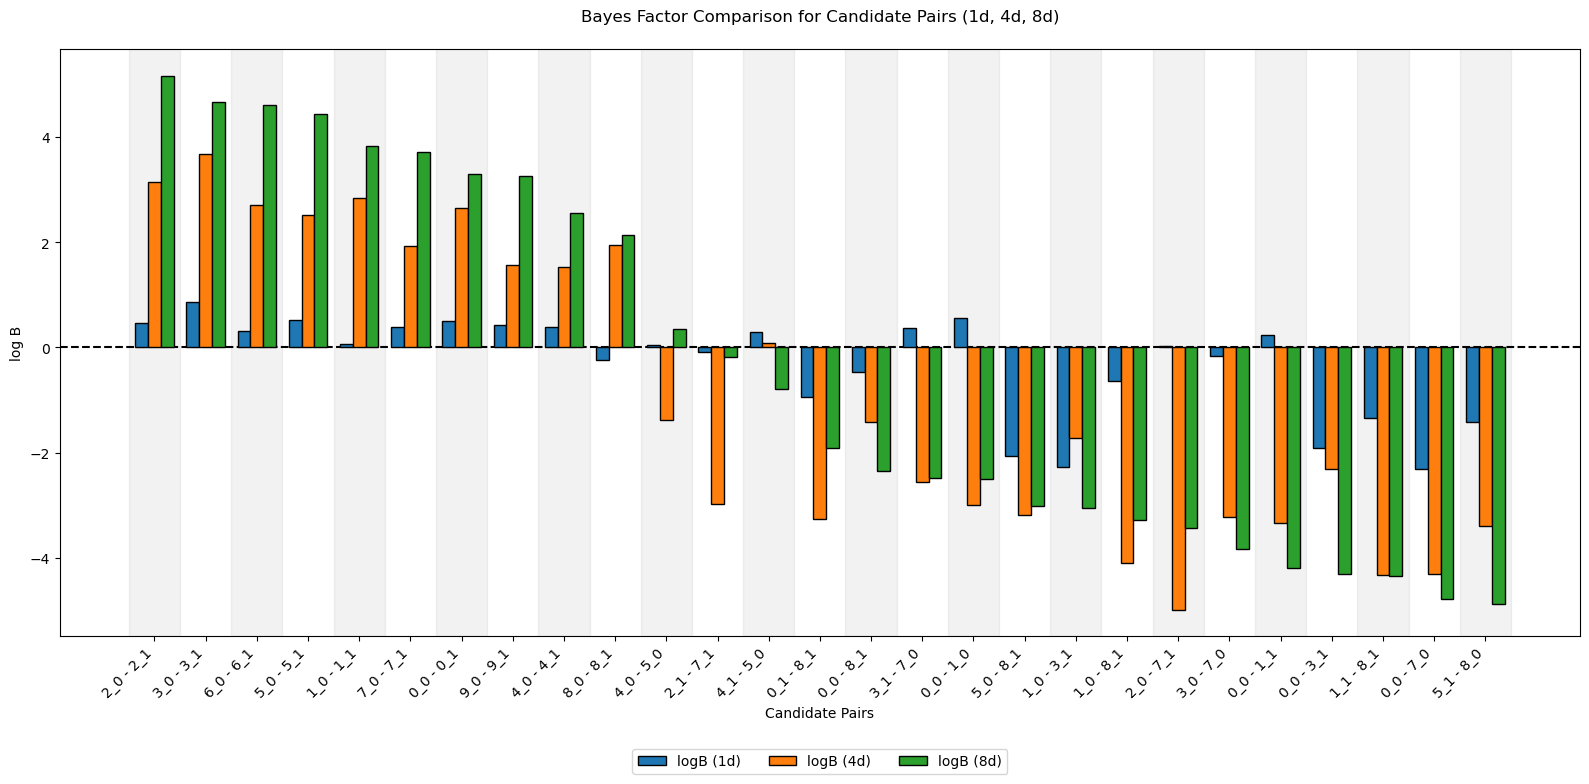

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
a = -5

df = pd.read_csv("../plots/bayes_factor_8d_results.csv")
df = df[(df['logB (1d)'] > a) & (df['logB (4d)'] > a) & (df['logB (8d)'] > a)].sort_values(by='logB (8d)', ascending=False)
x_pos = np.arange(len(df))
df['pair label'] = df['Signal_0'].astype(str) + " - " + df['Signal_1'].astype(str)

fig, ax = plt.subplots(figsize=(16, 8))
for i in range(len(df)):
    if i % 2 == 0:
        ax.axvspan(i - 0.5, i + 0.5, color='gray', alpha=0.1, zorder=0)

width = 0.25
ax.bar(x_pos - width, df['logB (1d)'], width, color='#1f77b4', edgecolor='black', label='logB (1d)', zorder=2)
ax.bar(x_pos,         df['logB (4d)'], width, color='#ff7f0e', edgecolor='black', label='logB (4d)', zorder=2)
ax.bar(x_pos + width, df['logB (8d)'], width, color='#2ca02c', edgecolor='black', label='logB (8d)', zorder=2)

ax.set_xticks(x_pos)
ax.set_xlabel('Candidate Pairs')
ax.set_xticklabels(df['pair label'], rotation=45, ha='right')
ax.set_ylabel('log B')
ax.axhline(y=0, color='black', linestyle='--', zorder=1)
ax.set_title('Bayes Factor Comparison for Candidate Pairs (1d, 4d, 8d)', pad=20)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=True, fontsize=10)

plt.tight_layout()
plt.savefig("../plots/logB_vertical_8d_comparison.png", dpi=300)
print("Plot saved as 'logB_vertical_8d_comparison.png' in '../plots/'.")


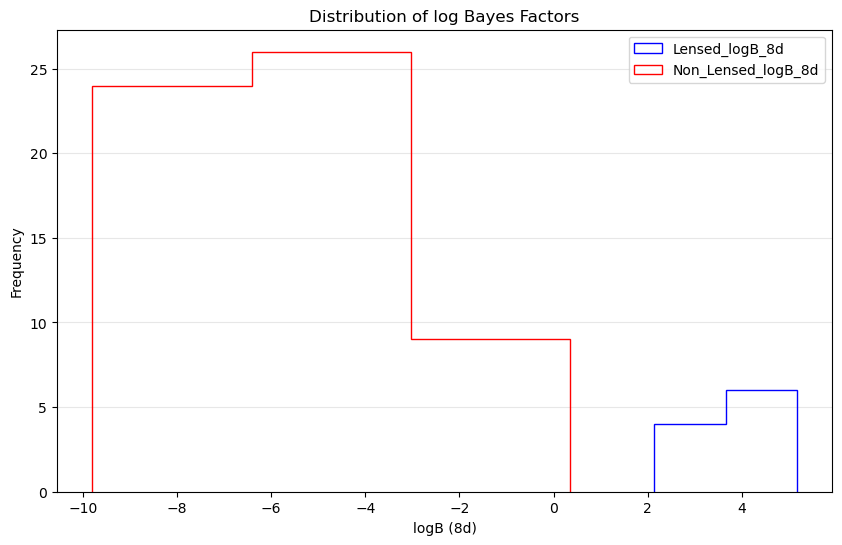

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
a= -10
df = pd.read_csv('../plots/bayes_factor_8d_results.csv')
df = df[(df['logB (1d)'] > a) & (df['logB (4d)'] > a) & (df['logB (8d)'] > a)]

def lensed(row):
    prefix_0 = row['Signal_0'].split('_')[0]
    prefix_1 = row['Signal_1'].split('_')[0]
    
    return prefix_0 == prefix_1

df['lensed'] = df.apply(lensed, axis=1)
lensed_logB_8d = df[df['lensed'] == True]['logB (8d)']
non_lensed_logB_8d = df[df['lensed'] == False]['logB (8d)']

plt.figure(figsize=(10, 6))
plt.hist(lensed_logB_8d, bins=2, label='Lensed_logB_8d', color='blue',histtype='step')
plt.hist(non_lensed_logB_8d, bins=3, label='Non_Lensed_logB_8d', color='red',histtype='step')

plt.xlabel('logB (8d)')
plt.ylabel('Frequency')
plt.title('Distribution of log Bayes Factors')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()


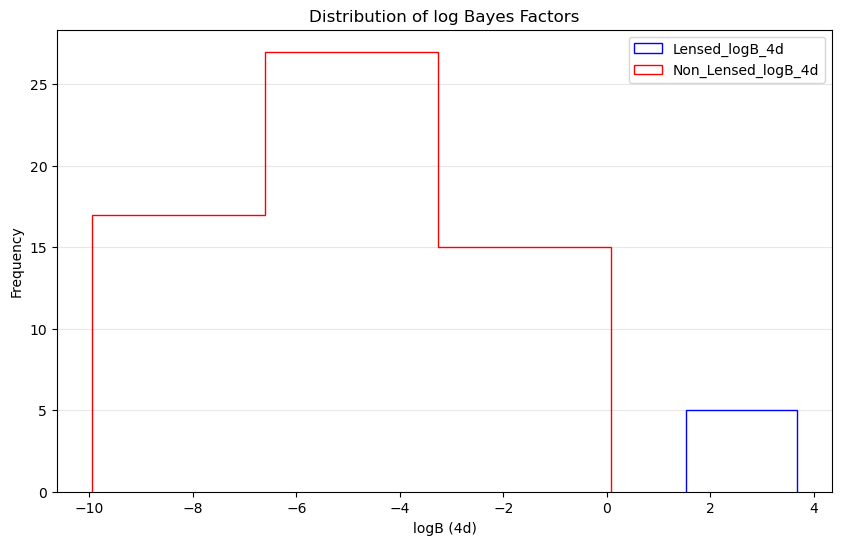

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
a= -10
df = pd.read_csv('../plots/bayes_factor_8d_results.csv')
df = df[(df['logB (1d)'] > a) & (df['logB (4d)'] > a) & (df['logB (8d)'] > a)]

def lensed(row):
    prefix_0 = row['Signal_0'].split('_')[0]
    prefix_1 = row['Signal_1'].split('_')[0]
    
    return prefix_0 == prefix_1

df['lensed'] = df.apply(lensed, axis=1)
lensed_logB_4d = df[df['lensed'] == True]['logB (4d)']
non_lensed_logB_4d = df[df['lensed'] == False]['logB (4d)']

plt.figure(figsize=(10, 6))
plt.hist(lensed_logB_4d, bins=2, label='Lensed_logB_4d', color='blue',histtype='step')
plt.hist(non_lensed_logB_4d, bins=3, label='Non_Lensed_logB_4d', color='red',histtype='step')

plt.xlabel('logB (4d)')
plt.ylabel('Frequency')
plt.title('Distribution of log Bayes Factors')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()


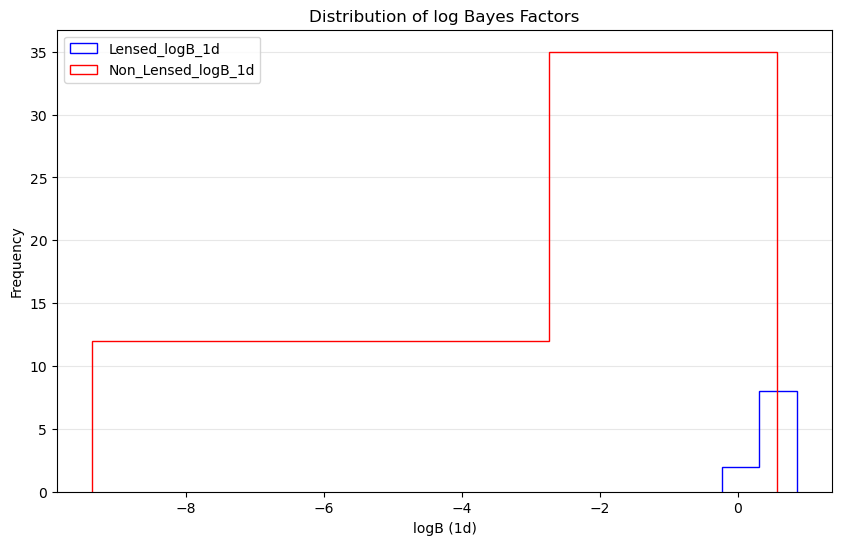

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
a= -10
df = pd.read_csv('../plots/bayes_factor_8d_results.csv')
df = df[(df['logB (1d)'] > a) & (df['logB (4d)'] > a) & (df['logB (8d)'] > a)]

def lensed(row):
    prefix_0 = row['Signal_0'].split('_')[0]
    prefix_1 = row['Signal_1'].split('_')[0]
    
    return prefix_0 == prefix_1

df['lensed'] = df.apply(lensed, axis=1)
lensed_logB_1d = df[df['lensed'] == True]['logB (1d)']
non_lensed_logB_1d = df[df['lensed'] == False]['logB (1d)']

plt.figure(figsize=(10, 6))
plt.hist(lensed_logB_1d, bins=2, label='Lensed_logB_1d', color='blue',histtype='step')
plt.hist(non_lensed_logB_1d, bins=3, label='Non_Lensed_logB_1d', color='red',histtype='step')

plt.xlabel('logB (1d)')
plt.ylabel('Frequency')
plt.title('Distribution of log Bayes Factors')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()
